# LV03 : Grafovski algoritmi

In [13]:
#  !pip install networkx

import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 2. Networkx library

In [15]:
# 2.1  Create empty graph

G = nx.Graph()
# Altermative: 
#G = nx.empty_graph(8);  

# Dodajaj povezave / Add edges 
G.add_edge(0,1); # Add connection between node 0 and 1
G.add_edge(0,2); 
G.add_edges_from([(1,3), (2,3), (3,4), (3,5), (4,6), (5,6), (6,7)]); #We can also add several connections at once

# add weight
G.edges[1,3]['weight'] = 0.3

# Izpisi vozlisca in povezave / Print nodes and edges
print(G.nodes)
print(G.edges)

[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (3, 5), (4, 6), (5, 6), (6, 7)]


{0: [0, 1], 1: [1, 2], 2: [1, 0], 3: [2, 1], 4: [3, 2], 5: [3, 0], 6: [4, 1], 7: [5, 1]}


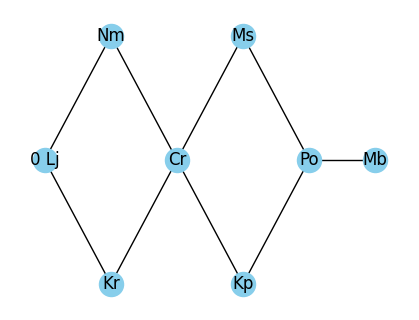

In [ ]:
# 2.2 Visualize the graph

# prepare an empty figure
plt.figure(figsize = [4,3])

## Graph layout / node positions
#pos = nx.spring_layout(G)
#pos = nx.kamada_kawai_layout(G)
pos = nx.circular_layout(G);
## Option: Define node positions manually as [x,y]
pos = { 0 : [0,1], 1 : [1,2], 2 : [1,0], 3 : [2,1], 4 : [3,2], 5 : [3,0], 6 : [4,1], 7 : [5,1] }

print(pos)
nx.draw(G, pos=pos, with_labels=False, node_color='skyblue') #draw the graph 

#Define node labels as a dictionary, key => node number, value => node name
labels={}
labels[0] = '0 Lj'
labels[1] = 'Nm'
labels[2] = 'Kr'
labels[3] = 'Cr'
labels[4] = 'Ms'
labels[5] = 'Kp'
labels[6] = 'Po'
labels[7] = 'Mb'
nx.draw_networkx_labels(G, pos, labels, font_size=12); #add labels

plt.show(); #show the graph

In [23]:
# 2.3 : Adjacency matrix
adjM = nx.to_numpy_array(G)
print(adjM)


[[0.  1.  1.  0.  0.  0.  0.  0. ]
 [1.  0.  0.  0.3 0.  0.  0.  0. ]
 [1.  0.  0.  1.  0.  0.  0.  0. ]
 [0.  0.3 1.  0.  1.  1.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  1.  0. ]
 [0.  0.  0.  1.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  1.  1.  0.  1. ]
 [0.  0.  0.  0.  0.  0.  1.  0. ]]


[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (1, 3), (2, 3), (3, 4), (3, 5), (4, 6), (5, 6), (6, 7)]
[[0.  1.  1.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.3 0.  0.  0.  0. ]
 [0.  0.  0.  1.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  1.  1.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  0.  0.  0.  0. ]]


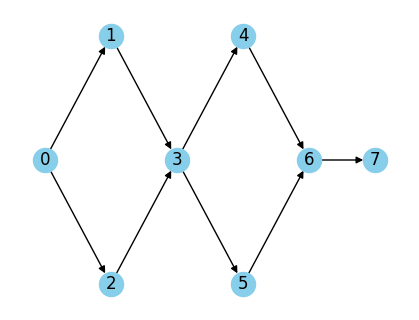

In [ ]:
# 2.4 Usmerjeni graf / Directed graph
D = nx.DiGraph()
# Dodajaj povezave / Add edges 
D.add_edge(0,1); # Add connection between node 0 and 1
D.add_edge(0,2); 
D.add_edges_from([(1,3), (2,3), (3,4), (3,5), (4,6), (5,6), (6,7)]); #We can also add several connections at once
# add weight
D.edges[1,3]['weight'] = 0.3
# Izpisi vozlisca in povezave / Print nodes and edges
print(D.nodes)
print(D.edges)
plt.figure(figsize = [4,3])
nx.draw(D, pos=pos, with_labels=True, node_color='skyblue') #draw the graph 
adjM = nx.to_numpy_array(D)
print(adjM)

### 3. Algorithms

In [ ]:
# 3.1 Load graph
G2 = nx.read_graphml('Slo_cities.graphml')
position = {}
for node in G2.nodes:
    print(node, " x,y: ", G2.nodes[node]['x'], G2.nodes[node]['y'] )
    position[node] = [G2.nodes[node]['x'], G2.nodes[node]['y']]
for edge in G2.edges:
    print(edge, ": ", G2.edges[edge])

Ljubljana  x,y:  0 0
Celje  x,y:  6 2
Maribor  x,y:  9 5
Ptuj  x,y:  10 4
Murska Sobota  x,y:  12 7
Krsko  x,y:  7 -1
Novo mesto  x,y:  5 -3
Kocevje  x,y:  2 -5
Postojna  x,y:  -3 -2
Koper  x,y:  -6 -6
Kranj  x,y:  -1 2
Jesenice  x,y:  -4 4
Nova Gorica  x,y:  -7 -1
Velenje  x,y:  5 4
Dravograd  x,y:  4 6
('Ljubljana', 'Kranj') :  {'km': 26}
('Ljubljana', 'Novo mesto') :  {'km': 72}
('Ljubljana', 'Celje') :  {'km': 73}
('Ljubljana', 'Postojna') :  {'km': 51}
('Ljubljana', 'Kocevje') :  {'km': 60}
('Celje', 'Krsko') :  {'km': 58}
('Celje', 'Maribor') :  {'km': 54}
('Celje', 'Velenje') :  {'km': 23}
('Maribor', 'Murska Sobota') :  {'km': 60}
('Maribor', 'Ptuj') :  {'km': 26}
('Maribor', 'Dravograd') :  {'km': 61}
('Krsko', 'Novo mesto') :  {'km': 37}
('Novo mesto', 'Kocevje') :  {'km': 49}
('Postojna', 'Nova Gorica') :  {'km': 63}
('Postojna', 'Koper') :  {'km': 64}
('Koper', 'Nova Gorica') :  {'km': 101}
('Kranj', 'Jesenice') :  {'km': 39}
('Jesenice', 'Nova Gorica') :  {'km': 178}
('Vel

{('Ljubljana', 'Kranj'): Text(-0.4999924274161458, 0.9999848548322934, '26'),
 ('Ljubljana',
  'Novo mesto'): Text(2.4999859504168835, -1.4999915702501312, '72'),
 ('Ljubljana', 'Celje'): Text(3.0000373253133112, 1.0000124417711085, '73'),
 ('Ljubljana',
  'Postojna'): Text(-1.5000504604540783, -1.000033640302716, '51'),
 ('Ljubljana', 'Kocevje'): Text(0.9999948034528625, -2.49998700863216, '60'),
 ('Celje', 'Krsko'): Text(6.4999848543666285, 0.500045436900109, '58'),
 ('Celje', 'Maribor'): Text(7.500015876721585, 3.5000158767215908, '54'),
 ('Celje', 'Velenje'): Text(5.500007572583849, 2.9999848548322916, '23'),
 ('Maribor',
  'Murska Sobota'): Text(10.500050460454075, 6.000033640302716, '60'),
 ('Maribor', 'Ptuj'): Text(9.499960919842122, 4.500039080157878, '26'),
 ('Maribor', 'Dravograd'): Text(6.500047076609915, 5.499990584678017, '61'),
 ('Krsko', 'Novo mesto'): Text(6.000028657726942, -1.9999713422730565, '37'),
 ('Novo mesto', 'Kocevje'): Text(3.4999495395459217, -4.000033640302

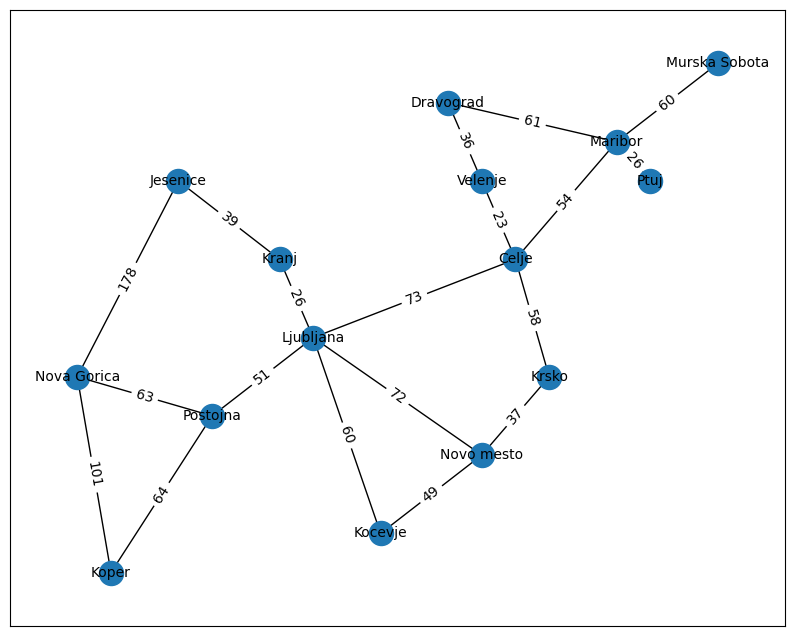

In [34]:
# 3.2 Vizualiziraj graf

# prepare an empty figure
plt.figure(figsize=[10,8])

#Plot the graph
nx.draw_networkx(G2, position, with_labels=True, font_size = 10)

edge_labels = {}
for edge in G2.edges:
    edge_labels[edge] = G2.edges[edge]['km']

nx.draw_networkx_edge_labels(G2, position, edge_labels)

### 3.3 Depth first search

In [8]:
# DFS Algorithm
from DataStructures import Stack

# Perform node visit
def visit_node(node, visited, visited_order, stack, graph, counter_list):
    visited.add(node)
    visited_order.append((counter_list[0], node))
    print("Visit: ", counter_list[0], node)
    counter_list[0]+=1
    for sosed in graph.adj[node]:
        if sosed not in visited:
            stack.push(sosed)
    # preglej kaj je na skladu
    # stack.print()

def dfs_traversal(inputGr, start_node):
    # Create a set to store visited vertices
    visited = set()
    # Create stack to store nodes to visit
    stack = Stack()
    # iterator over visits
    counter_list = [0]
    # Resulting sequence 
    node_order = []

    # ALGORITHM DFS 
    node = start_node
    visit_node(node, visited, node_order, stack, inputGr, counter_list)
    while stack.size() > 0:
        node = stack.pop()
        if node not in visited:
            visit_node(node, visited, node_order, stack, inputGr, counter_list)
    return node_order

# Test DFS
# nodes_dfs = dfs_traversal(G2, 'Ljubljana')



In [9]:
# 3.4 Create a directed graph
G3 = nx.DiGraph()



In [10]:
# 3.3 BFS Algorithm

## BFS Problem : Minimum number of edges to each node
## https://www.geeksforgeeks.org/minimum-number-of-edges-between-two-vertices-of-a-graph/?ref=lbp
from DataStructures import Queue

# Perform node visit
def visit_node(node, node_level, visited, visited_order, queue, graph, counter_list):
    visited.add(node)
    visited_order.append([node, node_level])
    node_level += 1

    #print("Visit: ", counter_list[0], node)
    counter_list[0]+=1
    for sosed in graph.adj[node]:
        if sosed not in visited:
            #if stack.indexOf(sosed) == None:
            queue.enqueue([sosed,node_level])
    # preglej kaj je v vrsti
    # queue.print()

# BFS Algorithm
# inputGr : graph
# start_node : starting node
# return : list of nodes in the order of visits
def min_edges(inputGr, start_node):
    # Create a set to store visited vertices
    visited = set()
    # Store nodes to be visited in the queue
    queue = Queue()
    # counter : the number of visits
    counter_list = [0]
    # Resulting sequence 
    node_order = []

    # ALGORITHM BFS
    node = start_node
    visit_node(node, 0, visited, node_order, queue, inputGr, counter_list)
    while queue.size() > 0:
        [node, level] = queue.dequeue()
        if node not in visited:
            visit_node(node, level, visited, node_order, queue, inputGr, counter_list)
    return node_order



In [11]:
# 3.5 : Minimum number of edges between two vertices of a graph

startNode = ''


In [12]:
# 3.6 : BFS tree

startNode = ''
print (list(nx.bfs_edges(G2,startNode)))

K = nx.bfs_tree(G2,startNode)

plt.figure()
nx.draw_networkx(K, position, with_labels=True, font_size = 8)


NetworkXError: The node  is not in the graph.

In [ ]:
# 3.7 : DFS tree
startNode = ''

# dfs tree



In [ ]:
# 3.8 : Shortest path between two vertices of a graph
start_node = ''
end_node = ''



## 4. Analiza ARNES omrežja


{'Ljubljana': [0, 0], 'Celje': [6, 2], 'Trbovlje': [5, 1], 'Maribor': [9, 5], 'Ptuj': [10, 4], 'Rogaska Slatina': [8, 2], 'Murska Sobota': [12, 7], 'Krsko': [7, -1], 'Novo mesto': [5, -3], 'Kocevje': [2, -5], 'Postojna': [-3, -2], 'Koper': [-6, -6], 'Portoroz': [-6.5, -7], 'Kranj': [-1, 2], 'Bled': [-4, 4], 'Nova Gorica': [-7, -1], 'Velenje': [5, 4], 'Dravograd': [4, 6], 'Kamnik': [1, 3]}
[('Ljubljana', 'Maribor'), ('Ljubljana', 'Koper'), ('Ljubljana', 'Nova Gorica'), ('Ljubljana', 'Kranj'), ('Ljubljana', 'Celje'), ('Ljubljana', 'Novo mesto'), ('Ljubljana', 'Portoroz'), ('Ljubljana', 'Trbovlje'), ('Ljubljana', 'Kocevje'), ('Ljubljana', 'Kamnik'), ('Celje', 'Maribor'), ('Celje', 'Trbovlje'), ('Maribor', 'Ptuj'), ('Maribor', 'Murska Sobota'), ('Ptuj', 'Rogaska Slatina'), ('Rogaska Slatina', 'Novo mesto'), ('Koper', 'Kranj'), ('Koper', 'Portoroz')]
{'weight': 20}


{('Ljubljana', 'Maribor'): Text(4.500017979444232, 2.500009988580132, '20'),
 ('Ljubljana', 'Koper'): Text(-2.9999623980838805, -2.9999623980838788, '10'),
 ('Ljubljana',
  'Nova Gorica'): Text(-3.499972145655194, -0.49999602080788463, '10'),
 ('Ljubljana', 'Kranj'): Text(-0.5000172462314385, 1.0000344924628752, '10'),
 ('Ljubljana', 'Celje'): Text(3.0000394165981543, 1.000013138866052, '1'),
 ('Ljubljana',
  'Novo mesto'): Text(2.4999797303462383, -1.499987838207744, '10'),
 ('Ljubljana',
  'Portoroz'): Text(-3.2499617068388034, -3.499958761211018, '10'),
 ('Koper', 'Kranj'): Text(-3.499994284880813, -1.9999908558092994, '10'),
 ('Novo mesto',
  'Rogaska Slatina'): Text(6.49996488296892, -0.5000585283851251, '10'),
 ('Ptuj', 'Rogaska Slatina'): Text(9.00000856537372, 3.0000085653737187, '10'),
 ('Celje', 'Maribor'): Text(7.499993086326862, 3.4999930863268673, '10'),
 ('Ptuj', 'Maribor'): Text(9.499992724508049, 4.500007275491955, '10'),
 ('Portoroz', 'Koper'): Text(-6.249988850206137,

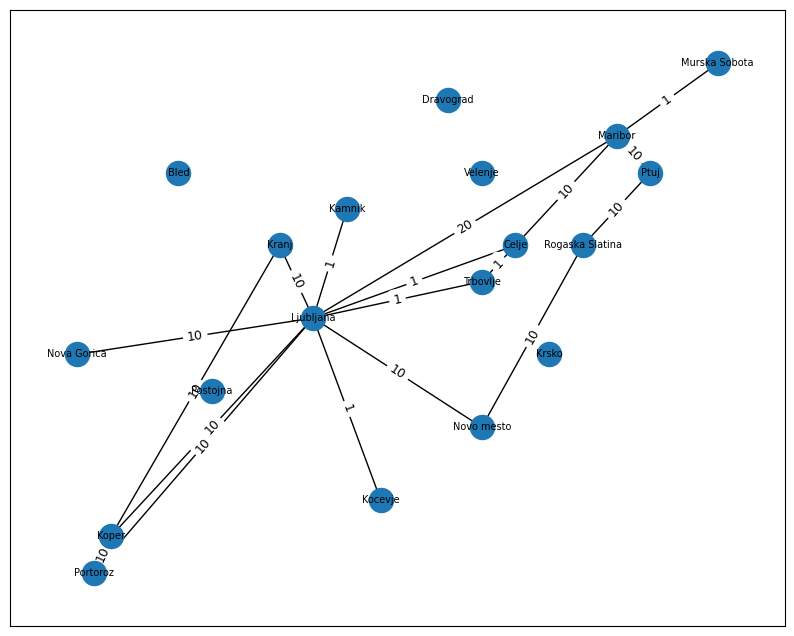

In [ ]:
# 4.1. TC NETWORK

# Example graph: ARNES Network Slovenia
GrArnes = nx.Graph()
nodes = [
    ("Ljubljana", {"x":0, "y": 0}),
    ("Celje", {"x":6, "y": 2}),
    ("Trbovlje", {"x":5, "y": 1}),
    ("Maribor", {"x":9, "y": 5}),
    ("Ptuj", {"x":10, "y": 4}),
    ("Rogaska Slatina", {"x":8, "y": 2}),
    ("Murska Sobota", {"x":12, "y": 7}),
    ("Krsko", {"x":7, "y": -1}),
    ("Novo mesto", {"x":5, "y": -3}),
    ("Kocevje", {"x":2, "y": -5}),
    ("Postojna", {"x":-3, "y": -2}),
    ("Koper", {"x":-6, "y": -6}),
    ("Portoroz", {"x":-6.5, "y": -7}),
    ("Kranj", {"x":-1, "y": 2}),
    ("Bled", {"x":-4, "y": 4}),
    ("Nova Gorica", {"x":-7, "y": -1}),
    ("Velenje", {"x":5, "y": 4}),
    ("Dravograd", {"x":4, "y": 6}),
    ("Kamnik", {"x":1, "y": 3}),
]
GrArnes.add_nodes_from(nodes)

# Pridobi pozicije iz podatkov
position = {}
for i in GrArnes.nodes:
    position[i] = [GrArnes.nodes[i]['x'], GrArnes.nodes[i]['y']]
print(position)

# Add edges with weights (Gb)
edge_list = [
    
    ("Ljubljana","Maribor", {"Gb":20}),
    
    ("Ljubljana","Koper", {"Gb":10}),
    ("Ljubljana","Nova Gorica", {"Gb":10}),
    
    ("Ljubljana","Kranj", {"Gb":10}),
    ("Ljubljana","Celje", {"Gb":10}),
    ("Ljubljana","Novo mesto", {"Gb":10}),
    ("Ljubljana","Portoroz", {"Gb":10}),
    ("Koper","Kranj", {"Gb":10}),
    ("Novo mesto","Rogaska Slatina", {"Gb":10}),
    ("Ptuj","Rogaska Slatina", {"Gb":10}),
    ("Celje","Maribor", {"Gb":10}),
    ("Ptuj","Maribor", {"Gb":10}),
    ("Portoroz","Koper", {"Gb":10}),
    
    ("Ljubljana","Trbovlje", {"Gb":1}),
    ("Celje","Trbovlje", {"Gb":1}),
    ("Ljubljana","Kocevje", {"Gb":1}),
    ("Ljubljana","Kamnik", {"Gb":1}),
    ("Ljubljana","Celje", {"Gb":1}),
    
   # ("Kocevje","Novo mesto", {"Gb":1}),
   # ("Krsko","Novo mesto", {"Gb":1}),
   # ("Krsko","Rogaska Slatina", {"Gb":1}),
   # ("Celje","Maribor", {"Gb":1}),
   # ("Celje","Velenje", {"Gb":1}),
   # ("Dravograd","Velenje", {"Gb":1}),
   # ("Dravograd","Maribor", {"Gb":1}),
   # ("Ptuj","Murska Sobota", {"Gb":1}),
    ("Maribor","Murska Sobota", {"Gb":1}),
   # ("Kranj","Bled", {"Gb":1}),
]

# Prepare edges with weights
w_edges = []
for edge in edge_list:
    w_edges.append((edge[0],edge[1],edge[2]["Gb"]))
# Add edges to the graph
GrArnes.add_weighted_edges_from(w_edges)

# Test print
print(GrArnes.edges)
print(GrArnes.edges[('Ljubljana', 'Maribor')])

edge_labels = {}
for e in edge_list:
    #print(e[2]["Gb"])
    edge_labels[(e[0],e[1])] = e[2]["Gb"]
#print(edge_labels )

# Plot the graph
plt.figure(figsize=[10,8])
nx.draw_networkx(GrArnes, position, with_labels=True, font_size = 7)
nx.draw_networkx_edge_labels(GrArnes, position, edge_labels=edge_labels, font_size = 9)

In [ ]:
# Adjacency matrix
adjM = nx.adjacency_matrix(GrArnes).toarray()
#adjM = nx.to_numpy_array(GrArnes)
#print(adjM)

In [ ]:
# 4.2 Povezanost

    


In [ ]:
# 4.3 Add edges with weights (distance)
edge_list = [
   ("Dravograd","Maribor", {"Gb":1}),
   ("Ptuj","Murska Sobota", {"Gb":1}),
]

w_edges = []
for edge in edge_list:
    w_edges.append((edge[0], edge[1], edge[2]["Gb"]))

print(w_edges)
GrArnes.add_weighted_edges_from(w_edges)



[('Dravograd', 'Maribor', 1), ('Ptuj', 'Murska Sobota', 1)]


### 4.4 Articulation points / Kritične točke

Zelo dober primer uporabe sprehoda v globino je algoritem za analizo omrežja in detekcijo kritičnih vozlišč. Kritična vozlišča so vozlišča katerih izpad bi omrežje razdelil v dve podomrežji med katerimi ni skupne povezave.


Articulation points:  ['Maribor', 'Ljubljana']


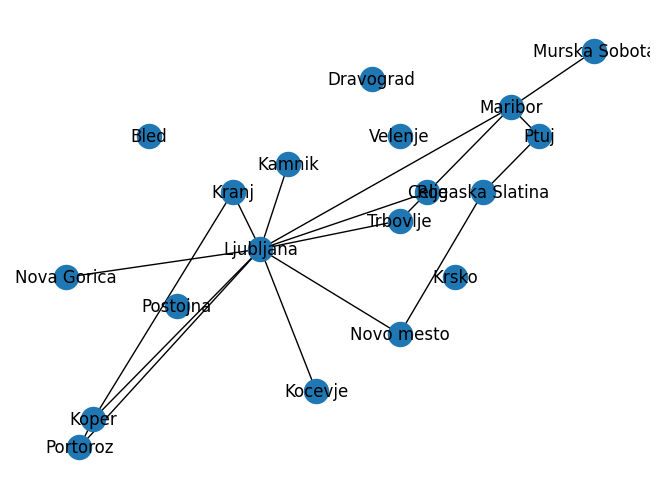

In [ ]:
# 4.4 Articulation points
#Plot the graph
nx.draw(GrArnes,position)
nx.draw_networkx_labels(GrArnes,position); #dodamo oznake vozlisc

apts = list(nx.articulation_points(GrArnes))
print( 'Articulation points: ' , apts)

### 4.5 SHORTEST PATH PROBLEM : najnižja cena

In [ ]:
# 4.5 Shortest path between two vertices of a graph
# Add costs to edges
for edge in GrArnes.edges:
    GrArnes.edges[edge]['cost'] = 100.0 / GrArnes.edges[edge]['weight']
    #print(edge, ' lastnosti: ',GrArnes.edges[edge])

# Uporabi shortest path algoritem z upoštevanjem stroškov
start_node = 'Ljubljana'
end_node = 'Murska Sobota'



In [ ]:
# 4.6 : Finding maximum flow
# https://networkx.org/documentation/stable/reference/algorithms/flow.html
# MAXIMUM FLOW
start_node = ''
end_node = ''

flow_value, flow_dict = nx.maximum_flow(GrArnes, start_node, end_node, capacity='weight')
print('Total flow ', start_node, ' to ', end_node, ': ', flow_value)

for node in flow_dict:
    print(node, flow_dict[node])

NetworkXError: node  not in graph

In [ ]:
# 4.7 : Visualize flow graph

flowG = nx.DiGraph()
#flowG.clear_edges()
flowG.add_nodes_from(nodes)

for node in flow_dict:
    for n in flow_dict[node]:
        if flow_dict[node][n] > 0:
            flowG.add_edge(node, n, weight = flow_dict[node][n])


# Plot the graph
plt.figure(figsize = [14,10])
#nx.draw_networkx(
#nx.draw_networkx_edge_labels(

NameError: name 'flow_dict' is not defined